# 00 — Environment check

**Run this before the in-person day.**

Run the cell below. If it ends with `ALL CHECKS PASSED`, you are ready. If you
see anything else, post the error text in the channel — **before** Saturday. We
are not spending lab time on `pip`.

Installation:

```bash
python -m venv .venv
source .venv/bin/activate      # Windows: .venv\Scripts\activate
pip install -r requirements.txt
```

[ ok ] python >= 3.9  -- 3.9.6
[ ok ] core libraries import  -- numpy 2.0.2 | pandas 2.3.3 | matplotlib 3.9.4 | seaborn 0.13.2 | sklearn 1.6.1
[ ok ] matplotlib can draw  -- a figure should appear below
[ ok ] repo datasets are readable  -- data/qcommerce_orders.csv -> (244, 9)
[ ok ] repo helper module imports  -- bootcamp module ok (3 figures)
[ ok ] sklearn bundled data  -- sklearn sample data ok ((150, 4))

ALL CHECKS PASSED -- see you Saturday.


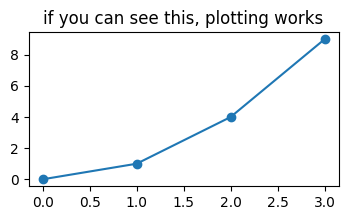

In [1]:
import sys
import pathlib
import traceback

problems = []


def check(label, fn):
    """Run one check, print a pass/fail line, and never stop the notebook.

    Each check returns a short detail string on success. Failures are
    collected so the summary at the bottom can list all of them at once --
    much more useful than stopping at the first error.
    """
    try:
        detail = fn()
    except Exception:
        problems.append(label)
        print(f"[FAIL] {label}")
        print(traceback.format_exc(limit=1))
    else:
        print(f"[ ok ] {label}" + (f"  -- {detail}" if detail else ""))


def repo_root():
    """The repo root, whether jupyter started here or in notebooks/."""
    root = pathlib.Path.cwd()
    return root.parent if root.name == "notebooks" else root


def python_version():
    major, minor = sys.version_info[:2]
    assert (major, minor) >= (3, 9), f"python {major}.{minor} is too old"
    return sys.version.split()[0]


def libraries():
    import numpy, pandas, matplotlib, seaborn, sklearn
    return " | ".join(f"{m.__name__} {m.__version__}"
                      for m in (numpy, pandas, matplotlib, seaborn, sklearn))


def plotting():
    # Importing matplotlib is not enough -- the backend has to actually render.
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(4, 2))
    ax.plot([0, 1, 4, 9], marker="o")
    ax.set_title("if you can see this, plotting works")
    return "a figure should appear below"


def datasets():
    # Catches the classic "I downloaded the notebook but not the repo".
    import pandas as pd
    orders = pd.read_csv(repo_root() / "data" / "qcommerce_orders.csv")
    return f"data/qcommerce_orders.csv -> {orders.shape}"


def helper_module():
    sys.path.insert(0, str(repo_root()))
    import bootcamp
    return f"bootcamp module ok ({len(bootcamp.__all__)} figures)"


def bundled_data():
    # Notebook 01 uses iris for the PCA section; it ships inside sklearn.
    from sklearn.datasets import load_iris
    return f"sklearn sample data ok ({load_iris().data.shape})"


check("python >= 3.9", python_version)
check("core libraries import", libraries)
check("matplotlib can draw", plotting)
check("repo datasets are readable", datasets)
check("repo helper module imports", helper_module)
check("sklearn bundled data", bundled_data)

print()
if problems:
    print("PROBLEMS:", ", ".join(problems))
    print("Send the traceback above to the channel before Saturday.")
else:
    print("ALL CHECKS PASSED -- see you Saturday.")